# 01 — Data acquisition

NDVI, LST and SPEI extracted over a delineated olive orchard at Jendouba,
north-western Tunisia, March 2000 – December 2024.

| Variable | Product | Resolution | Cadence |
|---|---|---|---|
| NDVI | MODIS MOD13Q1 v061 | 250 m | 16-day |
| LST | MODIS MOD11A2 v061, daytime | 1 km | 8-day |
| SPEI at 1, 3, 6 and 12 months | CSIC SPEIbase v2.11 | 0.5° | monthly |

The study area is a hand-delineated polygon rather than the single pixel used in
the source work, so every observation here is a spatial aggregate over the orchard
rather than a point sample. The boundary is versioned with the code as
`olive-jendouba-polygon.geojson`, which makes the study area a fixed, inspectable
object rather than something redrawn each time.

The record starts in March 2000 because MOD13Q1 begins on 18 February 2000, leaving
February a partial month, and ends in December 2024, the last complete month in
SPEIbase v2.11.

Both MODIS products are screened against their own quality bands before use. The
notebook closes with five validation checks. Nothing downstream should be trusted
until all five pass.

**Outputs** — into `data/raw/`: the native-cadence NDVI and LST series, the monthly
SPEI series, and a merged monthly table.

In [1]:
import json

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

ee.Initialize(project="caramel-slice-498315-i6")

with open("../olive-jendouba-polygon.geojson") as f:
    gj = json.load(f)

AREA = ee.Geometry.Polygon(gj["features"][0]["geometry"]["coordinates"])
CENTROID = AREA.centroid(maxError=1)

START, END = "2000-03-01", "2024-12-31"

area_m2 = AREA.area().getInfo()
print(f"area {area_m2:,.0f} m2 = {area_m2 / 1e6:.3f} km2")
print(f"  MODIS 250 m : {area_m2 / 250**2:5.1f} pixels")
print(f"  MODIS 1 km  : {area_m2 / 1000**2:5.2f} pixels")

area 644,387 m2 = 0.644 km2
  MODIS 250 m :  10.3 pixels
  MODIS 1 km  :  0.64 pixels


## NDVI — MODIS MOD13Q1

16-day composites at 250 m, reduced over the orchard polygon.

Each observation is the area-weighted spatial **mean** of the pixels intersecting
the polygon. The mean is used rather than the median for three reasons.

1. It is the physical quantity of interest — orchard-scale greenness, rather than a
   representative pixel.
2. Earth Engine weights partially covered edge pixels by their overlap, so
   incomplete coverage at the boundary is already handled correctly.
3. It is additive. Notebook 02 decomposes at native cadence and aggregates the
   components to monthly afterwards; under the mean, trend and seasonal still sum
   to the series exactly. The median has no such property.

The spatial standard deviation and the pixel count are retained alongside the mean
as a per-date record of how uniform the orchard was.

MOD13Q1 stores NDVI as a signed integer scaled by 10 000, rescaled below to the
physical range.

In [2]:
def extract(collection, band, scale, name):
    """Spatial mean, spread and pixel count over the orchard, per date."""
    ic = (ee.ImageCollection(collection)
            .filterDate(START, END)
            .filterBounds(AREA)
            .select(band))

    reducer = (ee.Reducer.mean()
                 .combine(ee.Reducer.stdDev(), sharedInputs=True)
                 .combine(ee.Reducer.count(), sharedInputs=True))

    def sample(img):
        stats = img.reduceRegion(reducer=reducer, geometry=AREA, scale=scale)
        return ee.Feature(None, {
            "date": img.date().format("YYYY-MM-dd"),
            name: stats.get(f"{band}_mean"),
            f"{name}_sd": stats.get(f"{band}_stdDev"),
            f"{name}_n": stats.get(f"{band}_count"),
        })

    rows = ee.FeatureCollection(ic.map(sample)).getInfo()["features"]
    df = pd.DataFrame([r["properties"] for r in rows])
    df["date"] = pd.to_datetime(df["date"])
    return df.sort_values("date").reset_index(drop=True)


ndvi = extract("MODIS/061/MOD13Q1", "NDVI", 250, "NDVI")
ndvi[["NDVI", "NDVI_sd"]] *= 0.0001

print(len(ndvi), "composites,",
      ndvi.date.min().date(), "->", ndvi.date.max().date())
print(ndvi[["NDVI", "NDVI_sd", "NDVI_n"]].describe().round(4))

571 composites, 2000-03-05 -> 2024-12-18
           NDVI   NDVI_sd    NDVI_n
count  571.0000  571.0000  571.0000
mean     0.4504    0.0420   18.1646
std      0.1715    0.0179    0.5502
min      0.2144    0.0163   18.0000
25%      0.2949    0.0288   18.0000
50%      0.3881    0.0388   18.0000
75%      0.6067    0.0518   18.0000
max      0.7901    0.1929   20.0000


## LST — MODIS MOD11A2

Daytime land surface temperature, 8-day composites at 1 km.

The orchard is 0.64 of a 1 km pixel in area, and because it straddles a pixel
boundary the reduction draws on four partially covered pixels — an effective
footprint of roughly 4 km², of which the orchard is about 16%. **Land surface
temperature cannot be isolated to this study area.**

The series is kept because it is the strongest predictor in every attribution
result obtained so far, but those two facts have to be read together: the variable
the models lean on hardest is the one whose measurement footprint is larger than
the area under study. This is declared as a limitation in the paper.

MOD11A2 stores LST as an unsigned integer scaled by 0.02 in kelvin, converted below
to degrees Celsius.

In [3]:
lst = extract("MODIS/061/MOD11A2", "LST_Day_1km", 1000, "LST")
lst[["LST", "LST_sd"]] *= 0.02
lst["LST"] -= 273.15

print(len(lst), "composites,",
      lst.date.min().date(), "->", lst.date.max().date())
print(lst[["LST", "LST_sd", "LST_n"]].describe().round(3))
print("\nmissing:", lst["LST"].isna().sum())

1141 composites, 2000-03-05 -> 2024-12-26
            LST    LST_sd     LST_n
count  1133.000  1133.000  1141.000
mean     28.893     0.424     3.955
std      11.796     0.421     0.373
min       3.283     0.000     0.000
25%      17.833     0.166     4.000
50%      28.372     0.279     4.000
75%      39.809     0.534     4.000
max      52.333     3.824     4.000

missing: 8


## SPEI — CSIC SPEIbase v2.11

Standardized Precipitation-Evapotranspiration Index at four accumulation scales,
**1, 3, 6 and 12 months**. Published monthly on a 0.5° grid, so no temporal
aggregation is required.

### Why these scales

Bounouh et al. (2024) used 1 to 4 months. That ladder is dense at the short end and
has no long member, which leaves the model unable to see a multi-season water
deficit. The scales used here are the ones the Mediterranean drought literature
converges on: 1 month for the immediate soil-moisture signal, 3 and 6 for deficit
accumulated across a growing season, and 12 for the hydrological year. Gouveia et
al. (2017) find Mediterranean vegetation responds most strongly between 3 and 12
months, and Almeida-Ñauñay et al. (2022) report the same for semi-arid rangeland.

The annual table further down shows the practical consequence: SPEI-12 separates
the published drought years far more cleanly than SPEI-1 does.

### Why the centroid rather than the polygon

At 0.5° a grid cell is roughly 55 km across, so the orchard covers about 0.02% of
one cell. That is small enough that `reduceRegion` with a mean reducer returns
null — the overlap weights underflow to zero. Sampling the centroid with
`Reducer.first()` returns the value of the containing cell, which is the number the
mean would have produced had it not underflowed.

The drought index is therefore a regional quantity in this study, not a local one,
and the paper should say so plainly.

In [4]:
SPEI_BANDS = ["SPEI_01_month", "SPEI_03_month", "SPEI_06_month", "SPEI_12_month"]
SPEI_COLS = [f"SPEI_{int(b[5:7])}" for b in SPEI_BANDS]

spei_ic = (ee.ImageCollection("CSIC/SPEI/2_11")
             .filterDate(START, END)
             .filterBounds(AREA)
             .select(SPEI_BANDS))


def sample_spei(img):
    stats = img.reduceRegion(ee.Reducer.first(), CENTROID, 55660)
    return ee.Feature(None, stats.set("date", img.date().format("YYYY-MM-dd")))


rows = ee.FeatureCollection(spei_ic.map(sample_spei)).getInfo()["features"]
spei = pd.DataFrame([r["properties"] for r in rows])
spei["date"] = pd.to_datetime(spei["date"])
spei = (spei.rename(columns=dict(zip(SPEI_BANDS, SPEI_COLS)))
            .sort_values("date").reset_index(drop=True))

print(len(spei), "months,", spei.date.min().date(), "->", spei.date.max().date())
print(spei[SPEI_COLS].describe().round(3))

298 months, 2000-03-01 -> 2024-12-01
        SPEI_1   SPEI_3   SPEI_6  SPEI_12
count  298.000  298.000  298.000  298.000
mean    -0.278   -0.350   -0.406   -0.492
std      1.047    1.043    1.049    1.095
min     -2.225   -2.612   -2.637   -2.802
25%     -1.078   -1.194   -1.234   -1.383
50%     -0.360   -0.362   -0.400   -0.524
75%      0.534    0.415    0.376    0.315
max      2.235    2.448    2.372    2.055


## Quality screening

Both MODIS products carry a per-pixel quality band, and neither was used in the
first version of this notebook. The omission was found by inspection: a single
NDVI composite, 18 December 2004, appeared as an isolated spike in the finest
wavelet band of notebook 02 — a midwinter value of 0.234 between neighbours of
0.559 and 0.655. Vegetation cannot lose half its greenness in sixteen days and
recover it in the next sixteen.

**NDVI.** MOD13Q1's `SummaryQA` grades each pixel 0 (good), 1 (marginal),
2 (snow or ice) or 3 (cloudy). It is averaged over the polygon with the same
area-weighted reducer as the NDVI itself. Composites averaging 2 or worse are set
to missing; marginal pixels are retained, as is usual practice, since they are
usable and discarding them would remove a further fifteen composites for little
gain.

The flagged composites share a property that matters more than their number: every
one reads **lower** than its neighbours. Cloud is bright in the red band and dim in
the near-infrared, so contamination always depresses NDVI. It is a one-directional
bias rather than noise, and averaging does not remove it.

Missing composites are interpolated in notebook 02, exactly as the cloud gaps in
LST already are, so the treatment of the two products is symmetric.

**LST.** MOD11A2 already withholds pixels it cannot retrieve through cloud — those
are the gaps found above. For the composites it does produce, `QC_Day` bits 6–7
give an estimated retrieval error. The check below confirms whether any retained
composite exceeds 2 K; if none do, no further masking is warranted.

In [5]:
qa = extract("MODIS/061/MOD13Q1", "SummaryQA", 250, "QA")[["date", "QA"]]
ndvi = ndvi.drop(columns="QA", errors="ignore").merge(qa, on="date", how="left")

CLOUD = ndvi["QA"] >= 2
s = ndvi["NDVI"]
neighbours = (s.shift(1) + s.shift(-1)) / 2

print(f"NDVI composites flagged cloud or snow: {CLOUD.sum()} of {len(ndvi)}\n")
print(ndvi.loc[CLOUD, ["date", "NDVI", "QA"]]
          .assign(date=lambda t: t["date"].dt.date,
                  neighbours=neighbours[CLOUD], deviation=(s - neighbours)[CLOUD])
          .round(3).to_string(index=False))

ndvi.loc[CLOUD, ["NDVI", "NDVI_sd"]] = np.nan


def lst_quality(img):
    qc = img.select("QC_Day")
    flags = ee.Image.cat([qc.bitwiseAnd(3).rename("mandatory"),
                          qc.rightShift(6).bitwiseAnd(3).rename("error")])
    stats = flags.reduceRegion(ee.Reducer.mean(), AREA, 1000)
    return ee.Feature(None, stats.set("date", img.date().format("YYYY-MM-dd")))


rows = ee.FeatureCollection(
    ee.ImageCollection("MODIS/061/MOD11A2")
      .filterDate(START, END).filterBounds(AREA).map(lst_quality)
).getInfo()["features"]
lst_qc = pd.DataFrame([r["properties"] for r in rows])

print(f"\nLST error flag, area-weighted (0: <=1 K, 1: <=2 K, 2: <=3 K, 3: >3 K)")
print(f"  max over record {lst_qc['error'].max():.2f}")
print(f"  composites with estimated error above 2 K: {(lst_qc['error'] > 1).sum()}")

NDVI composites flagged cloud or snow: 8 of 571

      date  NDVI  QA  neighbours  deviation
2000-03-21 0.583 3.0       0.655     -0.072
2001-11-17 0.304 3.0       0.329     -0.026
2002-03-22 0.447 3.0       0.598     -0.151
2004-12-18 0.234 3.0       0.607     -0.373
2012-02-02 0.615 3.0       0.683     -0.068
2022-03-22 0.589 3.0       0.723     -0.133
2023-12-03 0.374 3.0       0.426     -0.052
2024-02-18 0.718 3.0       0.778     -0.060



LST error flag, area-weighted (0: <=1 K, 1: <=2 K, 2: <=3 K, 3: >3 K)
  max over record 1.00
  composites with estimated error above 2 K: 0


## Monthly aggregation

NDVI and LST composites are aggregated to calendar months by arithmetic **mean**
and assigned to the month in which the observation window begins. Missing
composites — cloud-flagged NDVI and withheld LST — are skipped, so each month is
the mean of its valid composites.

The mean is used rather than the median for the additivity reason given above: the
wavelet decomposition in notebook 02 is applied at native cadence and its
components are aggregated to monthly afterwards, and only under the mean do trend
and seasonal still sum to the series exactly. Over this record the two statistics
are in any case near-identical, since most months contain two 16-day composites.

SPEI is published monthly and needs no aggregation; its timestamps are normalised
to month-start so the three sources align on a common index.

In [6]:
ndvi_monthly = ndvi.set_index("date")[["NDVI", "NDVI_sd"]].resample("MS").mean()
lst_monthly  = lst.set_index("date")[["LST", "LST_sd"]].resample("MS").mean()

spei_monthly = spei.set_index("date")[SPEI_COLS]
spei_monthly.index = spei_monthly.index.to_period("M").to_timestamp()

master = ndvi_monthly.join(lst_monthly).join(spei_monthly, how="inner")

print(master.shape)
print(master.isna().sum().to_string())
print(master.head(3).round(4))

(298, 8)
NDVI       0
NDVI_sd    0
LST        0
LST_sd     0
SPEI_1     0
SPEI_3     0
SPEI_6     0
SPEI_12    0
              NDVI  NDVI_sd      LST  LST_sd  SPEI_1  SPEI_3  SPEI_6  SPEI_12
date                                                                         
2000-03-01  0.7023   0.0561  23.3282  0.3356 -1.7357 -2.2339 -1.4298  -1.8030
2000-04-01  0.5430   0.0437  28.9590  0.3494 -0.6947 -1.9320 -1.2856  -1.6968
2000-05-01  0.3377   0.0354  36.0573  0.3616  0.7090 -1.1561 -1.8439  -1.4755


## Saving

Four files. The native-cadence NDVI and LST series are kept separately because
notebook 02 decomposes each at its own sampling interval rather than after monthly
aggregation — a correction established during the Phase 1 reproduction, where
decomposing the monthly series instead degraded every component.

The 16-day NDVI file keeps the area-averaged `QA` column, so the masking can be
audited or changed downstream without returning to Earth Engine.

In [7]:
ndvi.to_csv("../data/raw/orchard_ndvi_16day.csv", index=False)
lst.to_csv("../data/raw/orchard_lst_8day.csv", index=False)
spei.to_csv("../data/raw/orchard_spei_monthly.csv", index=False)
master.to_csv("../data/raw/orchard_monthly.csv")

print("16-day NDVI", ndvi.shape,
      "| 8-day LST", lst.shape,
      "| SPEI", spei.shape,
      "| monthly", master.shape)

16-day NDVI (571, 5) | 8-day LST (1141, 4) | SPEI (298, 5) | monthly (298, 8)


## Validation

Five checks that the series are correctly located in space and time, and that the
land cover beneath them is stable, before anything downstream uses them.

| # | Check | Expectation |
|---|---|---|
| 1 | Seasonal phasing | LST peaks in summer; NDVI troughs in the same months |
| 2 | NDVI–LST coupling | strong negative correlation |
| 3 | Drought years | negative annual SPEI in the years reported for Tunisia |
| 4 | Spatial uniformity | within-orchard spread small against the seasonal range |
| 5 | Land-cover stability | no canopy-establishment signal across the record |

Checks 1 and 2 confirm the extraction and the merge. Check 3 confirms the drought
index belongs to this location. Checks 4 and 5 are specific to an area-based study
over a long record and have no equivalent in a single-pixel design.

### Checks 1, 2 and 4 — phasing, coupling and spatial spread

In [8]:
clim = master.groupby(master.index.month)[["NDVI", "LST"]].mean().round(3)
print(clim.to_string())

print(f"\nNDVI peaks month {clim['NDVI'].idxmax():2d}, troughs month {clim['NDVI'].idxmin():2d}")
print(f"LST  peaks month {clim['LST'].idxmax():2d}, troughs month {clim['LST'].idxmin():2d}")
print(f"NDVI climatological amplitude: {clim['NDVI'].max() - clim['NDVI'].min():.3f}")

print(f"\nNDVI vs LST, same month: r = {master['NDVI'].corr(master['LST']):.3f}")
print(f"within-orchard NDVI sd: mean {master.NDVI_sd.mean():.4f}, "
      f"max {master.NDVI_sd.max():.4f}")
print(f"range of monthly NDVI:  {master.NDVI.max() - master.NDVI.min():.4f}")

       NDVI     LST
date               
1     0.614  13.946
2     0.681  15.679
3     0.701  20.332
4     0.611  25.562
5     0.380  32.981
6     0.298  41.111
7     0.273  45.398
8     0.279  44.300
9     0.300  37.540
10    0.339  31.211
11    0.419  21.909
12    0.502  15.105

NDVI peaks month  3, troughs month  7
LST  peaks month  7, troughs month  1
NDVI climatological amplitude: 0.428

NDVI vs LST, same month: r = -0.818
within-orchard NDVI sd: mean 0.0422, max 0.0993
range of monthly NDVI:  0.5527


### Check 3 — drought years, and the dates of largest spatial spread

Bounouh et al. (2021) report 2000–2002, 2005, 2007, 2009, 2011, 2013 and 2015–2016
as drought years in Tunisia. Annual mean SPEI should be negative in most of them,
and the longer accumulation scales should discriminate more sharply than the
1-month one.

The extended record adds two events the 2003–2021 window could not contain: the
2000–2002 drought at the start, and the 2022–2024 drought at the end, which proves
to be the most severe in the series. Since 2022–2024 is the intended test period,
the models will be asked to forecast a drought with no analogue in their training
data.

The dates of largest within-orchard spread are listed alongside. A large spatial
standard deviation means part of the polygon was contaminated on that date, most
often by cloud; if that reading is right these dates should fall in winter.

In [9]:
annual = master.groupby(master.index.year)[SPEI_COLS].mean().round(2)
print(annual.to_string())

print("\nhighest within-orchard spread:")
print(master.nlargest(6, "NDVI_sd")[["NDVI", "NDVI_sd"]].round(4))

      SPEI_1  SPEI_3  SPEI_6  SPEI_12
date                                 
2000   -0.47   -0.76   -1.11    -1.52
2001   -0.39   -0.51   -0.61    -0.70
2002   -0.10   -0.44   -1.01    -1.76
2003    0.16    0.65    1.16     1.78
2004    0.14    0.40    0.66     0.80
2005   -0.01    0.07    0.37     0.95
2006   -0.27   -0.33   -0.35    -0.13
2007   -0.12    0.03    0.03    -0.37
2008   -0.49   -0.70   -1.00    -1.21
2009    0.06    0.44    0.73     0.88
2010    0.05    0.04   -0.08    -0.40
2011    0.09    0.29    0.57     0.66
2012   -0.48   -0.60   -0.46    -0.04
2013    0.06   -0.14   -0.43    -0.94
2014   -0.42   -0.59   -0.48    -0.24
2015   -0.26   -0.15   -0.04     0.17
2016   -0.39   -0.78   -1.08    -1.56
2017   -0.72   -0.92   -1.15    -1.15
2018   -0.04    0.08   -0.12    -0.83
2019    0.11    0.08    0.34     0.50
2020   -0.26   -0.37   -0.37    -0.44
2021   -0.81   -1.08   -1.18    -1.16
2022   -1.09   -1.55   -1.89    -2.06
2023   -0.53   -0.98   -1.45    -2.30
2024   -0.81

### The three inputs over the full record

One figure to confirm the data is sane before any modelling touches it: NDVI, LST
and the 12-month SPEI on a shared time axis.

The bands on the top two panels are ±1 within-orchard standard deviation — how much
the pixels inside the polygon disagree on each date. Where the band is narrow the
orchard is behaving as a single surface; where it widens, it is not.

The grey block marks **2022–2024**, the intended test period. Keeping it visible is
deliberate: the table above showed it is the driest stretch in the record, so the
test set is harder than the training set, and a reader should be able to see that
rather than have to be told.

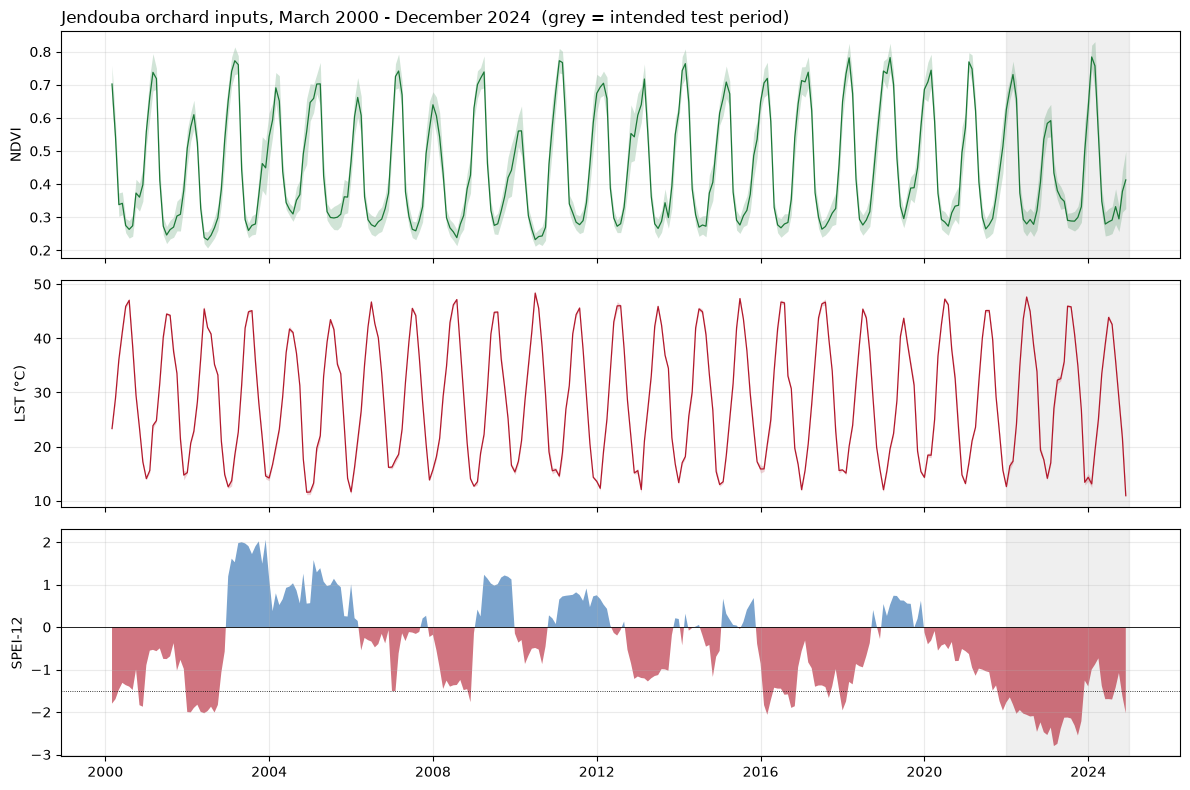

In [10]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
d = master.index

TEST_START, TEST_END = pd.Timestamp("2022-01-01"), pd.Timestamp("2024-12-31")
for ax in axes:
    ax.axvspan(TEST_START, TEST_END, color="grey", alpha=0.12, zorder=0)
    ax.grid(alpha=0.25)

axes[0].plot(d, master["NDVI"], lw=0.9, color="#1b7837")
axes[0].fill_between(d, master["NDVI"] - master["NDVI_sd"],
                        master["NDVI"] + master["NDVI_sd"],
                     color="#1b7837", alpha=0.20, lw=0)
axes[0].set_ylabel("NDVI")

axes[1].plot(d, master["LST"], lw=0.9, color="#b2182b")
axes[1].fill_between(d, master["LST"] - master["LST_sd"],
                        master["LST"] + master["LST_sd"],
                     color="#b2182b", alpha=0.20, lw=0)
axes[1].set_ylabel("LST (°C)")

s = master["SPEI_12"]
axes[2].fill_between(d, s, 0, where=s < 0, color="#b2182b", alpha=0.6,
                     lw=0, interpolate=True)
axes[2].fill_between(d, s, 0, where=s >= 0, color="#2166ac", alpha=0.6,
                     lw=0, interpolate=True)
axes[2].axhline(0, color="k", lw=0.6)
axes[2].axhline(-1.5, color="k", lw=0.6, ls=":")
axes[2].set_ylabel("SPEI-12")

axes[0].set_title("Jendouba orchard inputs, March 2000 - December 2024  "
                  "(grey = intended test period)", loc="left")
fig.tight_layout()
fig.savefig("../figures/01_input_series.png", dpi=150, bbox_inches="tight")
plt.show()

### Check 5 — is this the same orchard throughout?

A 25-year record is only usable if the land cover beneath it did not change. Were
the orchard planted during the record, the wavelet trend component in notebook 02
would be measuring a canopy filling in, and every attribution built on that
component would be explaining the wrong thing.

The phenology provides the test. The herbaceous layer between the trees dies every
summer, so the July–September NDVI minimum is, near enough, the woody canopy alone.
A mature orchard holds that floor flat; an establishing one raises it by 0.15 to
0.25 as the canopy closes, then plateaus. The February–April maximum is plotted
beside it as a control — dominated by the herbaceous layer either way, it should
track rainfall rather than canopy age.

summer floor:  slope +0.00090/yr   p 0.0869   change over record +0.022
winter peak:  slope +0.00227/yr   p 0.1990   change over record +0.054


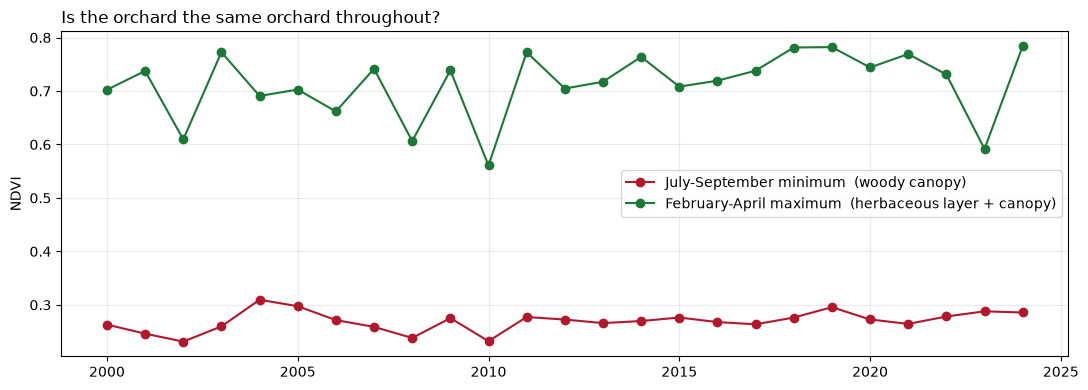

In [11]:
summer = master[master.index.month.isin([7, 8, 9])]
floor = summer.groupby(summer.index.year)["NDVI"].min()

winter = master[master.index.month.isin([2, 3, 4])]
ceiling = winter.groupby(winter.index.year)["NDVI"].max()

for label, s in [("summer floor", floor), ("winter peak", ceiling)]:
    r = linregress(s.index, s.values)
    print(f"{label}:  slope {r.slope:+.5f}/yr   p {r.pvalue:.4f}   "
          f"change over record {r.slope * (s.index[-1] - s.index[0]):+.3f}")

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(floor.index, floor.values, "o-", color="#b2182b",
        label="July-September minimum  (woody canopy)")
ax.plot(ceiling.index, ceiling.values, "o-", color="#1b7837",
        label="February-April maximum  (herbaceous layer + canopy)")
ax.set_ylabel("NDVI")
ax.grid(alpha=0.25)
ax.legend(loc="center right")
ax.set_title("Is the orchard the same orchard throughout?", loc="left")
fig.tight_layout()
fig.savefig("../figures/01_land_cover_stability.png", dpi=150, bbox_inches="tight")
plt.show()

## What notebook 01 established

**Study area.** 0.644 km²: about 10.3 MODIS NDVI pixels, so the orchard is resolved
at 250 m, and 0.64 of a 1 km LST pixel spread across four partially covered pixels,
so it is not resolved thermally. The coordinate published by Bounouh et al. falls
inside the polygon, which settles an open question from the Phase 1 reproduction:
the pixel used in the source work is genuinely in the orchard, so whatever
non-olive signal it carries arises from sub-pixel mixing rather than a misplaced
point.

**Record.** March 2000 – December 2024, 298 complete months, no missing values
after the merge. That is 31% longer than the 2003–2021 window of the source work,
and the extension is not cosmetic: it adds the 2000–2002 drought at the start and
the 2022–2024 drought at the end, the latter the most severe in the series.

**Quality screening.** Eight NDVI composites are flagged cloudy across the whole
polygon and set to missing; every one read lower than its neighbours, by up to 0.373
on 18 December 2004, which is the signature of cloud rather than of vegetation.
Retained LST composites all carry an estimated retrieval error of 2 K or less, so no
further LST masking is needed. Masking moves the NDVI climatological amplitude from
0.420 to 0.428 and removes the single largest within-orchard spread in the record.

**All five checks pass.** LST peaks in July and NDVI troughs in the same month;
their correlation is strongly negative; annual SPEI is negative in most of the
published drought years and most clearly at the 12-month scale; within-orchard
spread is a small fraction of the seasonal range, and its largest values fall in
winter, consistent with cloud. The summer NDVI floor rises only 0.022 across 24
years (p = 0.087) — an order of magnitude below an establishment signal — and
high-resolution imagery from 2004 shows the planting grid already present. The
orchard is mature throughout, so the full record is usable and the trend component
cannot be an artefact of canopy growth.

**One finding to carry into the modelling.** The NDVI climatology swings by 0.428
across the year and peaks in **March**, while the woody canopy varies by only 0.08
from one year to the next. Olives are evergreen: a pure canopy signal would swing
by roughly 0.10 to 0.15, and would not peak before the summer growth flush. A large
amplitude with an early-spring maximum is the signature of annual herbaceous
growth. Both the seasonal cycle and the interannual variability at this site are
therefore dominated by the vegetation growing between the trees rather than by the
trees themselves.

This is a property of a 250 m sensor and not a defect of the study area — no
instrument at this resolution can separate canopy from orchard floor — but it is
rarely stated in this literature, and it governs how the attribution results in
notebook 05 must be read. Features that explain rainfall-driven herbaceous growth
should be expected to outrank features that explain olive physiology, and that is
the correct answer to the question these data actually pose.